Goal: assess whether LLM-generated synthetic queries exhibit lower lexical overlap with their corresponding original queries and source documents

In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt

from scipy.stats import ttest_rel, wilcoxon
from spacy.lang.nl.stop_words import STOP_WORDS
from nltk.stem.snowball import SnowballStemmer

In [ ]:
news = pd.read_csv("news_full_augmented.csv")
tenders = pd.read_csv("tenders_full_augmented.csv")
vabb = pd.read_csv("abstracts_full_augmented_clean.csv")

In [ ]:
print("News:", news.shape)
print("Tenders:", tenders.shape)
print("VABB:", vabb.shape)

News: (1000, 7)
Tenders: (1000, 7)
VABB: (1000, 7)


In [ ]:
display(news.head())

,query_id,corpus_id,score,original_query,document_text,synthetic_query,assigned_task_type
0,7834,7834,1,Verzetsman na 66 jaar begraven,Vandaag wordt in het Noord-Hollandse Heiloo ve...,Hoe werd een Nederlandse oorlogsslachtoffer na...,Task_1
1,124788,124788,1,"Als er kritiek is op de koning, gaat het altij...",Koning Willem-Alexander zit ruim duizend dagen...,Waarom is er kritiek op de financiële uitgaven...,Task_2
2,202109,202109,1,Steeds meer elektrische scooters op de weg,Steeds meer mensen kiezen voor een elektrische...,Klopt de bewering dat elektrische scooters ste...,Task_3
3,93877,93877,1,Militair met drugs gepakt op Curaçao,Op Curaçao is een Nederlandse militair van 25...,Wat is er bekend over de arrestatie van een mi...,Task_1
4,20941,20941,1,Deense grenscontroles vanaf dinsdag,Het Deense parlement heeft ingestemd met het o...,Uitleg over herinvoering grenscontroles en de ...,Task_2


In [ ]:
for name, data in {
    "News": news,
    "Tenders": tenders,
    "VABB": vabb
}.items():

    print(f"\n{name}")
    print("-" * 40)
    print("Rows:", len(data))
    print("Unique query IDs:", data["query_id"].nunique())
    print("Missing original queries:", data["original_query"].isna().sum())
    print("Missing synthetic queries:", data["synthetic_query"].isna().sum())
    print("Missing documents:", data["document_text"].isna().sum())


News
----------------------------------------
Rows: 1000
Unique query IDs: 1000
Missing original queries: 0
Missing synthetic queries: 0
Missing documents: 0

Tenders
----------------------------------------
Rows: 1000
Unique query IDs: 1000
Missing original queries: 0
Missing synthetic queries: 0
Missing documents: 0

VABB
----------------------------------------
Rows: 1000
Unique query IDs: 1000
Missing original queries: 0
Missing synthetic queries: 0
Missing documents: 0


In [ ]:
def tokenize(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    return re.findall(r"\b[\wÀ-ÿ]+\b", text, flags=re.UNICODE)

In [ ]:
def content_tokens(text):
    tokens = tokenize(text)
    return [token for token in tokens if token not in STOP_WORDS]

In [ ]:
def token_overlap(tokens_a, tokens_b):
    return len(set(tokens_a) & set(tokens_b))

In [ ]:
original = content_tokens(news.loc[0, "original_query"])
synthetic = content_tokens(news.loc[0, "synthetic_query"])

print("Original:", original)
print("Synthetic:", synthetic)
print("Shared words:", set(original) & set(synthetic))

Original: ['verzetsman', '66', 'jaar', 'begraven']
Synthetic: ['nederlandse', 'oorlogsslachtoffer', '66', 'jaar', 'eindelijk', 'begraven']
Shared words: {'jaar', '66', 'begraven'}


In [ ]:
def jaccard_similarity(tokens_a, tokens_b):
    a = set(tokens_a)
    b = set(tokens_b)

    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0

    return len(a & b) / len(a | b)

In [ ]:
jaccard_similarity(original, synthetic)

0.42857142857142855

In [ ]:
news["jaccard_orig_synth"] = news.apply(
    lambda row: jaccard_similarity(
        content_tokens(row["original_query"]),
        content_tokens(row["synthetic_query"])
    ),
    axis=1
)

In [ ]:
news["jaccard_orig_synth"].describe()

,jaccard_orig_synth
count,1000.000000
mean,0.080148
std,0.113315
min,0.000000
25%,0.000000
50%,0.000000
75%,0.125000
max,0.800000


In [ ]:
def overlap_proportion(tokens_a, tokens_b):
    a = set(tokens_a)
    b = set(tokens_b)

    if not a:
        return 0.0

    return len(a & b) / len(a)

In [ ]:
news["orig_doc_overlap"] = news.apply(
    lambda row: overlap_proportion(
        content_tokens(row["original_query"]),
        content_tokens(row["document_text"])
    ),
    axis=1
)

In [ ]:
news["synth_doc_overlap"] = news.apply(
    lambda row: overlap_proportion(
        content_tokens(row["synthetic_query"]),
        content_tokens(row["document_text"])
    ),
    axis=1
)

In [ ]:
ttest_rel(
    news["orig_doc_overlap"],
    news["synth_doc_overlap"]
)

TtestResult(statistic=np.float64(21.359487706469995), pvalue=np.float64(1.127006855131581e-83), df=np.int64(999))

In [ ]:
wilcoxon(
    news["orig_doc_overlap"],
    news["synth_doc_overlap"]
)

WilcoxonResult(statistic=np.float64(68681.5), pvalue=np.float64(9.521896430503886e-73))

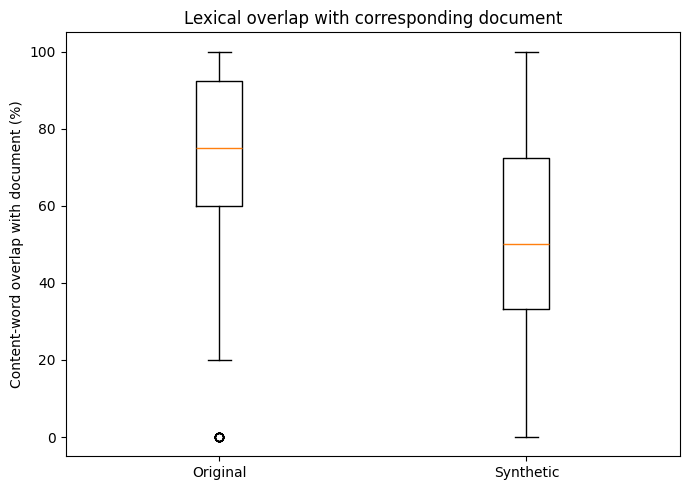

In [ ]:
plt.figure(figsize=(7, 5))

plt.boxplot([
    news["orig_doc_overlap"] * 100,
    news["synth_doc_overlap"] * 100
])

plt.xticks(
    [1, 2],
    ["Original", "Synthetic"]
)

plt.ylabel("Content-word overlap with document (%)")
plt.title("Lexical overlap with corresponding document")

plt.tight_layout()
plt.show()

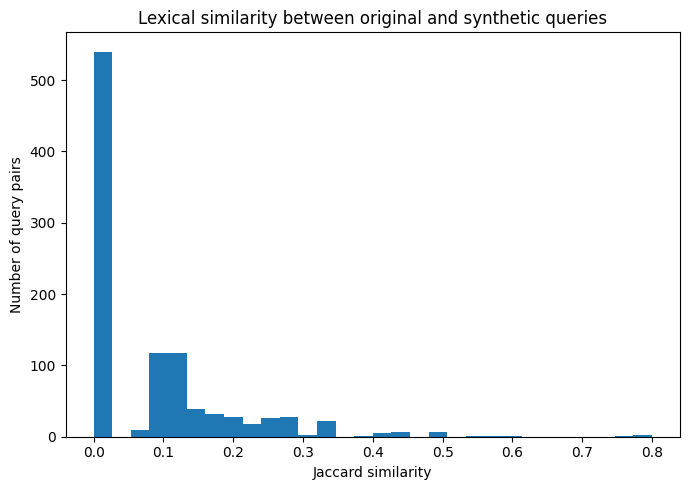

In [ ]:
plt.figure(figsize=(7, 5))

plt.hist(news["jaccard_orig_synth"], bins=30)

plt.xlabel("Jaccard similarity")
plt.ylabel("Number of query pairs")
plt.title("Lexical similarity between original and synthetic queries")

plt.tight_layout()
plt.show()

In [ ]:
def calculate_lexical_metrics(data):

    # Tokenize original query, synthetic query and document
    data["original_tokens"] = data["original_query"].apply(content_tokens)
    data["synthetic_tokens"] = data["synthetic_query"].apply(content_tokens)
    data["document_tokens"] = data["document_text"].apply(content_tokens)

    # Jaccard similarity: original query vs. synthetic query
    data["jaccard_orig_synth"] = data.apply(
        lambda row: jaccard_similarity(
            row["original_tokens"],
            row["synthetic_tokens"]
        ),
        axis=1
    )

    # Proportion of original query words occurring in the synthetic query
    data["orig_in_synth"] = data.apply(
        lambda row: overlap_proportion(
            row["original_tokens"],
            row["synthetic_tokens"]
        ),
        axis=1
    )

    # Proportion of original query words occurring in the document
    data["orig_in_doc"] = data.apply(
        lambda row: overlap_proportion(
            row["original_tokens"],
            row["document_tokens"]
        ),
        axis=1
    )

    # Proportion of synthetic query words occurring in the document
    data["synth_in_doc"] = data.apply(
        lambda row: overlap_proportion(
            row["synthetic_tokens"],
            row["document_tokens"]
        ),
        axis=1
    )

    return data

In [ ]:
news = calculate_lexical_metrics(news)
tenders = calculate_lexical_metrics(tenders)
vabb = calculate_lexical_metrics(vabb)

In [ ]:
summary = pd.DataFrame({
    "Dataset": ["News", "Tender", "VABB"],

    "Original → Document (%)": [
        news["orig_in_doc"].mean() * 100,
        tenders["orig_in_doc"].mean() * 100,
        vabb["orig_in_doc"].mean() * 100
    ],

    "Synthetic → Document (%)": [
        news["synth_in_doc"].mean() * 100,
        tenders["synth_in_doc"].mean() * 100,
        vabb["synth_in_doc"].mean() * 100
    ],

    "Difference (percentage points)": [
        (news["synth_in_doc"].mean() - news["orig_in_doc"].mean()) * 100,
        (tenders["synth_in_doc"].mean() - tenders["orig_in_doc"].mean()) * 100,
        (vabb["synth_in_doc"].mean() - vabb["orig_in_doc"].mean()) * 100
    ],

    "Jaccard Original ↔ Synthetic (%)": [
        news["jaccard_orig_synth"].mean() * 100,
        tenders["jaccard_orig_synth"].mean() * 100,
        vabb["jaccard_orig_synth"].mean() * 100
    ]
})

display(summary.round(2))

,Dataset,Original → Document (%),Synthetic → Document (%),Difference (percentage points),Jaccard Original ↔ Synthetic (%)
0,News,72.63,51.07,-21.56,8.01
1,Tender,62.43,37.58,-24.84,9.87
2,VABB,53.77,45.64,-8.13,9.04


In [ ]:
news["orig_in_doc"].mean()

np.float64(0.7263274531024531)

In [ ]:
news["synth_in_doc"].mean()

np.float64(0.5106873015873016)

In [ ]:
news["document_overlap_difference"] = (
    news["synth_in_doc"] - news["orig_in_doc"]
)

tenders["document_overlap_difference"] = (
    tenders["synth_in_doc"] - tenders["orig_in_doc"]
)

vabb["document_overlap_difference"] = (
    vabb["synth_in_doc"] - vabb["orig_in_doc"]
)

In [ ]:
display(
    news[
        [
            "query_id",
            "orig_in_doc",
            "synth_in_doc",
            "document_overlap_difference"
        ]
    ].head(10)
)

,query_id,orig_in_doc,synth_in_doc,document_overlap_difference
0,7834,1.000000,0.500000,-0.500000
1,124788,1.000000,0.500000,-0.500000
2,202109,1.000000,0.400000,-0.600000
3,93877,0.750000,0.750000,0.000000
4,20941,1.000000,0.400000,-0.600000
5,65169,0.666667,0.000000,-0.666667
6,80565,0.250000,0.600000,0.350000
7,103212,1.000000,0.800000,-0.200000
8,1113,0.250000,0.200000,-0.050000
9,145613,1.000000,0.833333,-0.166667


In [ ]:
from scipy.stats import ttest_rel

In [ ]:
news_ttest = ttest_rel(
    news["orig_in_doc"],
    news["synth_in_doc"]
)

print("Paired t-test — News")
print("t-statistic:", news_ttest.statistic)
print("p-value:", news_ttest.pvalue)

Paired t-test — News
t-statistic: 21.359487706469995
p-value: 1.127006855131581e-83


In [ ]:
datasets = {
    "News": news,
    "Tender": tenders,
    "VABB": vabb
}

ttest_results = []

for name, data in datasets.items():

    result = ttest_rel(
        data["orig_in_doc"],
        data["synth_in_doc"]
    )

    ttest_results.append({
        "Dataset": name,
        "t-statistic": result.statistic,
        "p-value": result.pvalue
    })

ttest_results = pd.DataFrame(ttest_results)

display(ttest_results)

,Dataset,t-statistic,p-value
0,News,21.359488,1.127007e-83
1,Tender,18.537728,3.653249e-66
2,VABB,6.726065,2.929509e-11


In [ ]:
display(ttest_results.round(4))

,Dataset,t-statistic,p-value
0,News,21.3595,0.0
1,Tender,18.5377,0.0
2,VABB,6.7261,0.0


In [ ]:
from scipy.stats import wilcoxon

In [ ]:
news_wilcoxon = wilcoxon(
    news["orig_in_doc"],
    news["synth_in_doc"]
)

print("Wilcoxon signed-rank test — News")
print("Test statistic:", news_wilcoxon.statistic)
print("p-value:", news_wilcoxon.pvalue)

Wilcoxon signed-rank test — News
Test statistic: 68681.5
p-value: 9.521896430503886e-73


In [ ]:
wilcoxon_results = []

for name, data in datasets.items():

    result = wilcoxon(
        data["orig_in_doc"],
        data["synth_in_doc"]
    )

    wilcoxon_results.append({
        "Dataset": name,
        "Wilcoxon statistic": result.statistic,
        "p-value": result.pvalue
    })

wilcoxon_results = pd.DataFrame(wilcoxon_results)

display(wilcoxon_results.round(4))

,Dataset,Wilcoxon statistic,p-value
0,News,68681.5,0.0
1,Tender,88628.5,0.0
2,VABB,162822.0,0.0


In [ ]:
statistical_results = ttest_results.merge(
    wilcoxon_results,
    on="Dataset"
)

display(statistical_results.round(4))

,Dataset,t-statistic,p-value_x,Wilcoxon statistic,p-value_y
0,News,21.3595,0.0,68681.5,0.0
1,Tender,18.5377,0.0,88628.5,0.0
2,VABB,6.7261,0.0,162822.0,0.0


In [ ]:
statistical_results["Significant (p < .05)"] = (
    statistical_results["p-value_x"] < 0.05
)

display(statistical_results.round(4))

,Dataset,t-statistic,p-value_x,Wilcoxon statistic,p-value_y,Significant (p < .05)
0,News,21.3595,0.0,68681.5,0.0,True
1,Tender,18.5377,0.0,88628.5,0.0,True
2,VABB,6.7261,0.0,162822.0,0.0,True


In [ ]:
ttest_results = ttest_results.rename(
    columns={"p-value": "p-value (t-test)"}
)

wilcoxon_results = wilcoxon_results.rename(
    columns={"p-value": "p-value (Wilcoxon)"}
)

statistical_results = ttest_results.merge(
    wilcoxon_results,
    on="Dataset"
)

display(statistical_results.round(4))

,Dataset,t-statistic,p-value (t-test),Wilcoxon statistic,p-value (Wilcoxon)
0,News,21.3595,0.0,68681.5,0.0
1,Tender,18.5377,0.0,88628.5,0.0
2,VABB,6.7261,0.0,162822.0,0.0


In [ ]:
import numpy as np

effect_results = []

for name, data in datasets.items():

    differences = data["orig_in_doc"] - data["synth_in_doc"]

    mean_difference = differences.mean()
    sd_difference = differences.std(ddof=1)

    cohens_dz = mean_difference / sd_difference

    effect_results.append({
        "Dataset": name,
        "Mean difference": mean_difference,
        "SD difference": sd_difference,
        "Cohen's dz": cohens_dz
    })

effect_results = pd.DataFrame(effect_results)

display(effect_results.round(4))

,Dataset,Mean difference,SD difference,Cohen's dz
0,News,0.2156,0.3193,0.6754
1,Tender,0.2484,0.4238,0.5862
2,VABB,0.0813,0.3824,0.2127


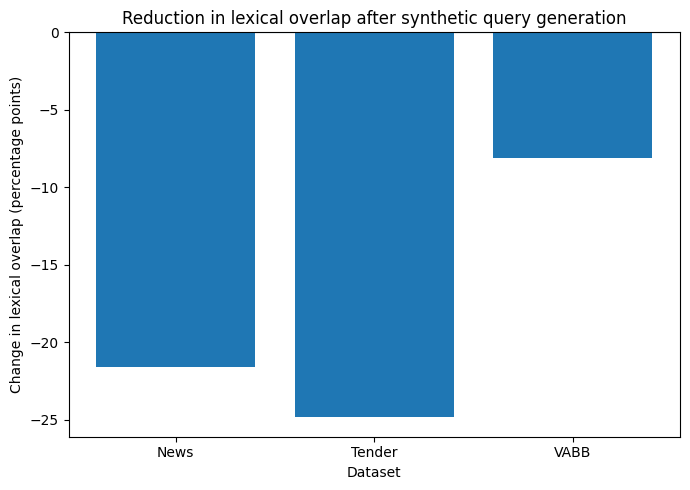

In [ ]:
datasets_names = ["News", "Tender", "VABB"]

mean_differences = [
    (news["synth_in_doc"].mean() - news["orig_in_doc"].mean()) * 100,
    (tenders["synth_in_doc"].mean() - tenders["orig_in_doc"].mean()) * 100,
    (vabb["synth_in_doc"].mean() - vabb["orig_in_doc"].mean()) * 100
]

plt.figure(figsize=(7, 5))

plt.bar(datasets_names, mean_differences)

plt.axhline(0, linewidth=0.8)

plt.ylabel("Change in lexical overlap (percentage points)")
plt.xlabel("Dataset")
plt.title("Reduction in lexical overlap after synthetic query generation")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

effect_results = []

for name, data in datasets.items():

    differences = data["orig_in_doc"] - data["synth_in_doc"]

    mean_difference = differences.mean()
    sd_difference = differences.std(ddof=1)

    cohens_dz = mean_difference / sd_difference

    effect_results.append({
        "Dataset": name,
        "Mean difference": mean_difference,
        "SD difference": sd_difference,
        "Cohen's dz": cohens_dz
    })

effect_results = pd.DataFrame(effect_results)

display(effect_results.round(4))

,Dataset,Mean difference,SD difference,Cohen's dz
0,News,2.156e-01,3.193e-01,6.754e-01
1,Tender,2.484e-01,4.238e-01,5.862e-01
2,VABB,8.130e-02,3.824e-01,2.127e-01


In [ ]:
task_results = []

for dataset_name, data in datasets.items():

    for task, group in data.groupby("assigned_task_type"):

        mean_original = group["orig_in_doc"].mean()
        mean_synthetic = group["synth_in_doc"].mean()
        difference = mean_synthetic - mean_original

        task_results.append({
            "Dataset": dataset_name,
            "Task": task,
            "N": len(group),
            "Original → Document (%)": mean_original * 100,
            "Synthetic → Document (%)": mean_synthetic * 100,
            "Difference (percentage points)": difference * 100,
            "Jaccard (%)": group["jaccard_orig_synth"].mean() * 100
        })

task_results = pd.DataFrame(task_results)

display(task_results.round(2))

,Dataset,Task,N,Original → Document (%),Synthetic → Document (%),Difference (percentage points),Jaccard (%)
0,News,Task_1,334,7.414e+01,5.362e+01,-2.052e+01,9.140e+00
1,News,Task_2,333,7.163e+01,4.680e+01,-2.483e+01,6.980e+00
2,News,Task_3,333,7.212e+01,5.278e+01,-1.934e+01,7.920e+00
3,Tender,Task_1,334,5.987e+01,3.917e+01,-2.070e+01,1.032e+01
4,Tender,Task_2,333,6.488e+01,4.049e+01,-2.438e+01,1.137e+01
5,Tender,Task_3,333,6.255e+01,3.309e+01,-2.946e+01,7.920e+00
6,VABB,Task_1,333,5.247e+01,4.837e+01,-4.110e+00,9.630e+00
7,VABB,Task_2,333,5.399e+01,4.416e+01,-9.830e+00,8.700e+00
8,VABB,Task_3,334,5.485e+01,4.439e+01,-1.046e+01,8.790e+00


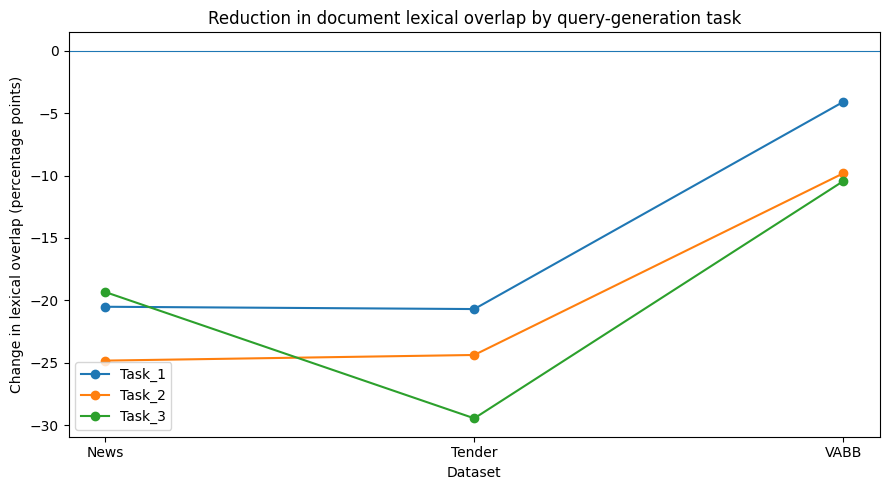

In [ ]:
import matplotlib.pyplot as plt

plot_data = task_results.copy()

plt.figure(figsize=(9, 5))

for task in plot_data["Task"].unique():
    subset = plot_data[plot_data["Task"] == task]

    plt.plot(
        subset["Dataset"],
        subset["Difference (percentage points)"],
        marker="o",
        label=task
    )

plt.axhline(0, linewidth=0.8)
plt.ylabel("Change in lexical overlap (percentage points)")
plt.xlabel("Dataset")
plt.title("Reduction in document lexical overlap by query-generation task")
plt.legend()
plt.tight_layout()
plt.show()

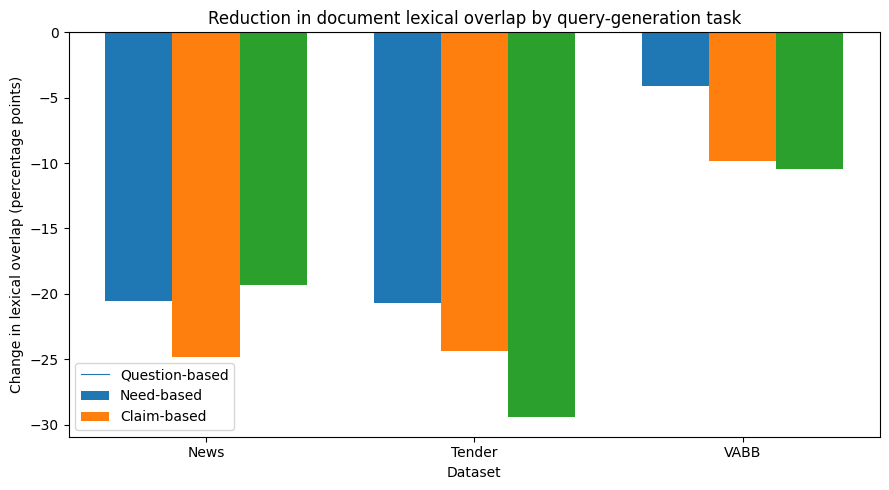

In [ ]:
plt.figure(figsize=(9, 5))

x = np.arange(len(plot_data["Dataset"].unique()))
datasets_order = ["News", "Tender", "VABB"]
tasks = ["Task_1", "Task_2", "Task_3"]

width = 0.25

for i, task in enumerate(tasks):
    values = [
        plot_data[
            (plot_data["Dataset"] == dataset) &
            (plot_data["Task"] == task)
        ]["Difference (percentage points)"].iloc[0]
        for dataset in datasets_order
    ]

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=task
    )

plt.axhline(0, linewidth=0.8)
plt.xticks(x, datasets_order)
plt.ylabel("Change in lexical overlap (percentage points)")
plt.xlabel("Dataset")
plt.title("Reduction in document lexical overlap by query-generation task")
plt.legend(
    ["Question-based", "Need-based", "Claim-based"]
)

plt.tight_layout()
plt.show()

In [ ]:
for name, data in datasets.items():
    lengths = data["document_text"].apply(
        lambda x: len(content_tokens(x))
    )

    print(f"\n{name}")
    print(f"Mean:   {lengths.mean():.1f} tokens")
    print(f"Median: {lengths.median():.1f}")
    print(f"Max:    {lengths.max()}")


News
Mean:   123.7 tokens
Median: 101.5
Max:    1649

Tender
Mean:   33.0 tokens
Median: 21.0
Max:    430

VABB
Mean:   61.8 tokens
Median: 45.0
Max:    942


In [ ]:
for name, data in datasets.items():
    lengths = data["document_text"].apply(
        lambda x: len(tokenize(x))
    )

    print(f"{name}:")
    print(lengths.describe())

News:
count   1.000e+03
mean    2.543e+02
std     1.876e+02
min     2.600e+01
25%     1.438e+02
50%     2.050e+02
75%     3.052e+02
max     3.244e+03
Name: document_text, dtype: float64
Tender:
count   1.000e+03
mean    5.841e+01
std     7.037e+01
min     1.000e+00
25%     1.500e+01
50%     3.700e+01
75%     8.100e+01
max     9.580e+02
Name: document_text, dtype: float64
VABB:
count   1.000e+03
mean    1.193e+02
std     1.331e+02
min     2.000e+00
25%     3.100e+01
50%     9.050e+01
75%     1.660e+02
max     1.600e+03
Name: document_text, dtype: float64


In [ ]:
MAX_LENGTH = 512

for name, data in datasets.items():

    token_lengths = data["document_text"].apply(
        lambda x: len(tokenize(x))
    )

    n_total = len(data)
    n_over_limit = (token_lengths > MAX_LENGTH).sum()
    percentage = n_over_limit / n_total * 100

    print(f"\n{name}")
    print("-" * 40)
    print(f"Total documents: {n_total}")
    print(f"Documents > {MAX_LENGTH} tokens: {n_over_limit}")
    print(f"Percentage > {MAX_LENGTH}: {percentage:.2f}%")


News
----------------------------------------
Total documents: 1000
Documents > 512 tokens: 79
Percentage > 512: 7.90%

Tender
----------------------------------------
Total documents: 1000
Documents > 512 tokens: 2
Percentage > 512: 0.20%

VABB
----------------------------------------
Total documents: 1000
Documents > 512 tokens: 18
Percentage > 512: 1.80%


In [ ]:
from transformers import AutoTokenizer

model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Maximum sequence length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Maximum sequence length: 512


In [ ]:
for name, data in datasets.items():

    lengths = data["document_text"].apply(
        lambda x: len(tokenizer.tokenize(str(x)))
    )

    n_over_limit = (lengths > tokenizer.model_max_length).sum()

    print(
        f"{name}: {n_over_limit}/{len(data)} "
        f"documents exceed the model's maximum length "
        f"({n_over_limit / len(data) * 100:.2f}%)"
    )

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (752 > 512). Running this sequence through the model will result in indexing errors


News: 198/1000 documents exceed the model's maximum length (19.80%)
Tender: 19/1000 documents exceed the model's maximum length (1.90%)
VABB: 48/1014 documents exceed the model's maximum length (4.73%)


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
semantic_model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

semantic_model = SentenceTransformer(semantic_model_name)

print("Model loaded:", semantic_model_name)
print("Embedding dimension:", semantic_model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Embedding dimension: 768


/tmp/ipykernel_1693/2854051341.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dimension:", semantic_model.get_sentence_embedding_dimension())


In [ ]:
example_query = news.loc[0, "synthetic_query"]
example_document = news.loc[0, "document_text"]

query_embedding = semantic_model.encode(
    example_query,
    convert_to_numpy=True
)

document_embedding = semantic_model.encode(
    example_document,
    convert_to_numpy=True
)

similarity = cosine_similarity(
    query_embedding.reshape(1, -1),
    document_embedding.reshape(1, -1)
)[0][0]

print("Synthetic query:")
print(example_query)

print("\nSemantic similarity with document:")
print(similarity)

Synthetic query:
Hoe werd een Nederlandse oorlogsslachtoffer na 66 jaar eindelijk begraven?

Semantic similarity with document:
0.7079023


In [ ]:
print("Maximum sequence length:",
      semantic_model.max_seq_length)

Maximum sequence length: 128


In [ ]:
print(semantic_model)

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'XLMRobertaModel'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'mean', 'include_prompt': True})
)


In [ ]:
print("SentenceTransformer max sequence length:",
      semantic_model.max_seq_length)

print("Tokenizer max length:",
      semantic_model.tokenizer.model_max_length)

SentenceTransformer max sequence length: 128
Tokenizer max length: 128


In [ ]:
import torch
import transformers
import sentence_transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Sentence Transformers:", sentence_transformers.__version__)

PyTorch: 2.11.0+cpu
Transformers: 5.13.1
Sentence Transformers: 5.6.0


In [ ]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3",
    trust_remote_code=True
)

print("Maximum sequence length:", semantic_model.max_seq_length)

modules.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/734k [00:00<?, ?B/s]

custom_st.py:   0%|          | 0.00/8.88k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v3:
- custom_st.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/492 [00:00<?, ?it/s]

AttributeError: 'XLMRobertaLoRA' object has no attribute 'all_tied_weights_keys'

In [ ]:
embedding = semantic_model.encode(
    ["Dit is een Nederlandse testzin."],
    task="text-matching"
)

print(embedding.shape)

In [ ]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3-hf",
    trust_remote_code=False,
    config_kwargs={"subfolder": "text_matching"}
)

print("Model loaded successfully!")
print("Maximum sequence length:", semantic_model.max_seq_length)
print(
    "Embedding dimension:",
    semantic_model.get_sentence_embedding_dimension()
)

modules.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/729k [00:00<?, ?B/s]

ModuleNotFoundError: No module named 'custom_st'

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer(
    "Alibaba-NLP/gte-multilingual-base"
)

print("Model loaded successfully!")
print("Maximum sequence length:", semantic_model.max_seq_length)
print(
    "Embedding dimension:",
    semantic_model.get_sentence_embedding_dimension()
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/124k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/55.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

ValueError: Alibaba-NLP/new-impl You can inspect the repository content at https://hf.co/Alibaba-NLP/gte-multilingual-base.
Please pass the argument `trust_remote_code=True` to allow custom code to be run.

In [ ]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer(
    "Alibaba-NLP/gte-multilingual-base",
    trust_remote_code=True
)

print("Model loaded successfully!")
print("Maximum sequence length:", semantic_model.max_seq_length)
print(
    "Embedding dimension:",
    semantic_model.get_sentence_embedding_dimension()
)

configuration.py:   0%|          | 0.00/7.13k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- configuration.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling.py:   0%|          | 0.00/59.0k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- modeling.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors: reconstructing file:   0%|          |  0.00B /  611MB            

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!
Maximum sequence length: 8192
Embedding dimension: 768


/tmp/ipykernel_1693/2579582106.py:12: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  semantic_model.get_sentence_embedding_dimension()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

example_query = news.loc[0, "synthetic_query"]
example_document = news.loc[0, "document_text"]

query_embedding = semantic_model.encode(
    example_query,
    convert_to_numpy=True
)

document_embedding = semantic_model.encode(
    example_document,
    convert_to_numpy=True
)

print("Query embedding shape:", query_embedding.shape)
print("Document embedding shape:", document_embedding.shape)

IndexError: index 8389765489559954542 is out of bounds for dimension 0 with size 19

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/LaBSE")

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.02k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors: reconstructing file:   0%|          |  0.00B / 2.36MB            

2_Dense/model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer(
    "sentence-transformers/LaBSE"
)

print("Model loaded successfully!")
print("Maximum sequence length:", semantic_model.max_seq_length)
print(
    "Tokenizer maximum length:",
    semantic_model.tokenizer.model_max_length
)
print(
    "Embedding dimension:",
    semantic_model.get_sentence_embedding_dimension()
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded successfully!
Maximum sequence length: 256
Tokenizer maximum length: 256
Embedding dimension: 768


/tmp/ipykernel_1693/2855762728.py:15: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  semantic_model.get_sentence_embedding_dimension()


In [ ]:
for name, data in datasets.items():

    lengths = data["document_text"].apply(
        lambda x: len(
            semantic_model.tokenizer(
                str(x),
                add_special_tokens=True,
                truncation=False
            )["input_ids"]
        )
    )

    max_length = semantic_model.max_seq_length
    n_over_limit = (lengths > max_length).sum()

    print(f"\n{name}")
    print(f"Documents: {len(data)}")
    print(f"Documents > {max_length} tokens: {n_over_limit}")
    print(f"Percentage: {n_over_limit / len(data) * 100:.2f}%")


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (364 > 256). Running this sequence through the model will result in indexing errors



News
Documents: 1000
Documents > 256 tokens: 564
Percentage: 56.40%

Tender
Documents: 1000
Documents > 256 tokens: 45
Percentage: 4.50%

VABB
Documents: 1014
Documents > 256 tokens: 224
Percentage: 22.09%


In [ ]:
SentenceTransformer(
    "Snowflake/snowflake-arctic-embed-m-v2.0",
    trust_remote_code=True
)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/203 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/251k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/971 [00:00<?, ?B/s]

configuration_hf_alibaba_nlp_gte.py:   0%|          | 0.00/7.13k [00:00<?, ?B/s]

...

modeling_hf_alibaba_nlp_gte.py:   0%|          | 0.00/40.4k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/Snowflake/snowflake-arctic-embed-m-v2.0:
- modeling_hf_alibaba_nlp_gte.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.22GB            

model.safetensors: downloading bytes:           |  0.00B            

AssertionError: please install xformers

In [ ]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer(
    "Snowflake/snowflake-arctic-embed-m-v2.0",
    trust_remote_code=True
)

print("Model loaded successfully!")
print("Maximum sequence length:", semantic_model.max_seq_length)
print("Embedding dimension:", semantic_model.get_embedding_dimension())